# Preprocessing and EDA for TOXRIC Multiple Endpoint Acute Toxicity Dataset

This notebook:
1. Loads the dataset and inspects its structure.
2. Checks for missing values and ensures the target column is numeric.
3. Computes molecular weights from SMILES (optional, for EDA).
4. Performs exploratory data analysis on the transformed LD50 values.


In [22]:
!pip install rdkit

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load the dataset

In [24]:
file_path = '/content/drive/MyDrive/FYP/IRP/Data/TOXRIC Multiple Endpoint Acute Toxicity (Figshare)/multiple_endpoint_acute_toxicity_dataset_col.csv'
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (80081, 3)


,RTECS_ID,SMILES,rat_oral_LD50
0,21209143,O=S(=O)(O)SCCNCCCCCC1CCCCCC1,NaN
1,34811159,Cc1ccc2nc3c(c(NCC(C)C)c2c1)CCCC3,NaN
2,70637002,CC12COC(c3ccccc3)(OC1)OC2,NaN
3,41288259,Cc1cc(OCCCCCCN2CCSC2)nc2ccccc12,NaN
4,2183564,CN1CCC23c4c5ccc(O)c4OC2C(O)CCC3(O)C1C5,NaN


## 2. Initial inspection and cleaning

In [25]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80081 entries, 0 to 80080
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   RTECS_ID       80081 non-null  object 
 1   SMILES         80081 non-null  object 
 2   rat_oral_LD50  10190 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.8+ MB


In [26]:
# The target column is 'rat_oral_LD50'. Convert to numeric, coercing errors.
df['rat_oral_LD50'] = pd.to_numeric(df['rat_oral_LD50'], errors='coerce')
print(f"Rows with missing or non‑numeric target: {df['rat_oral_LD50'].isna().sum()}")

Rows with missing or non‑numeric target: 69891


In [27]:
# Drop rows with missing target
df = df.dropna(subset=['rat_oral_LD50']).copy()

In [28]:
# Check for missing SMILES
print(f"Missing SMILES: {df['SMILES'].isna().sum()}")
df = df.dropna(subset=['SMILES']).copy()

print(f"Shape after cleaning: {df.shape}")

Missing SMILES: 0
Shape after cleaning: (10190, 3)


## Check duplicates in SMILES

In [29]:
print(f"Unique SMILES: {df['SMILES'].nunique()}")

# Show duplicated SMILES
duplicated_smiles = df[df.duplicated('SMILES', keep=False)]
print(f"Number of rows with duplicated SMILES: {len(duplicated_smiles)}")
duplicated_smiles.sort_values('SMILES').head(10)

Unique SMILES: 10190
Number of rows with duplicated SMILES: 0


,RTECS_ID,SMILES,rat_oral_LD50


## 3. Compute molecular weights for further analysis

In [30]:
def mol_weight_from_smiles(smiles):
    """Calculate molecular weight from SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    return Descriptors.MolWt(mol)

df['MW'] = df['SMILES'].apply(mol_weight_from_smiles)
print(f"Number with valid MW: {df['MW'].notna().sum()}")

# Drop rows where MW could not be computed (optional, but recommended for consistency)
df = df.dropna(subset=['MW']).copy()
print(f"Shape after dropping invalid MW: {df.shape}")

[03:19:24] Explicit valence for atom # 4 Sn, 5, is greater than permitted


Number with valid MW: 10189
Shape after dropping invalid MW: (10189, 4)


## 4. Exploratory Data Analysis

In [31]:
# Basic statistics of rat_oral_LD50
print("Statistics of rat_oral_LD50 (‑log₁₀(mol/kg)):")
print(df['rat_oral_LD50'].describe())

Statistics of rat_oral_LD50 (‑log₁₀(mol/kg)):
count    10189.000000
mean         2.498576
std          0.892599
min          0.017765
25%          1.857795
50%          2.349092
75%          2.947597
max          9.541127
Name: rat_oral_LD50, dtype: float64


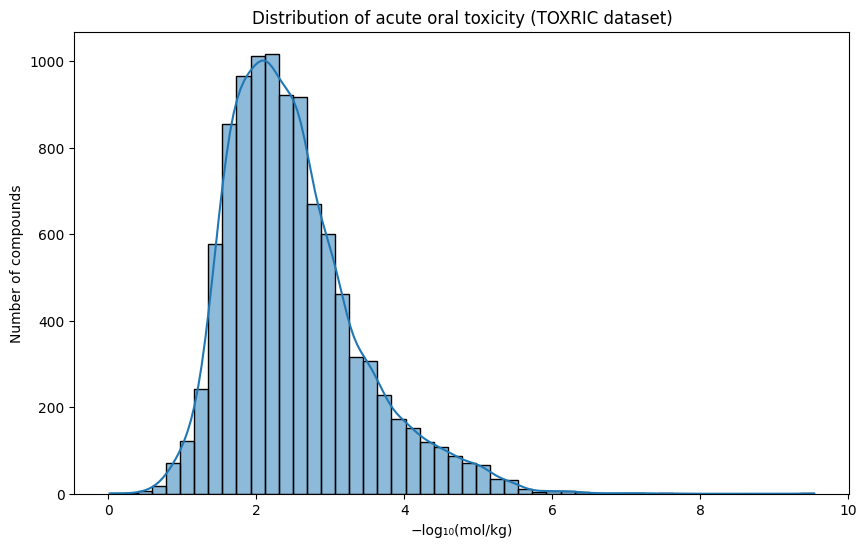

In [32]:
# Histogram
plt.figure(figsize=(10,6))
sns.histplot(df['rat_oral_LD50'], bins=50, kde=True)
plt.xlabel('−log₁₀(mol/kg)')
plt.ylabel('Number of compounds')
plt.title('Distribution of acute oral toxicity (TOXRIC dataset)')
plt.show()


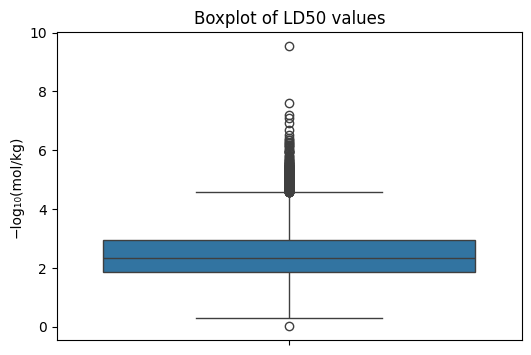

In [33]:
# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(y=df['rat_oral_LD50'])
plt.ylabel('−log₁₀(mol/kg)')
plt.title('Boxplot of LD50 values')
plt.show()

## Save the processed dataset

In [34]:
output_path = '/content/drive/MyDrive/FYP/IRP/Data/TOXRIC Multiple Endpoint Acute Toxicity (Figshare)/TOXRIC_acute_toxicity_processed.csv'
df.to_csv(output_path, index=False)
print(f"Saved processed data to {output_path}")

# For modeling, keep only SMILES and LD50
model_ready = df[['SMILES', 'rat_oral_LD50']].copy()
model_ready.to_csv('/content/drive/MyDrive/FYP/IRP/Data/TOXRIC Multiple Endpoint Acute Toxicity (Figshare)/TOXRIC_acute_toxicity_model_ready.csv', index=False)

Saved processed data to /content/drive/MyDrive/FYP/IRP/Data/TOXRIC Multiple Endpoint Acute Toxicity (Figshare)/TOXRIC_acute_toxicity_processed.csv


In [35]:
len(df['SMILES'].unique())

10189